In [ ]:
! pip install seaborn

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
coffee_sales = pd.read_csv('Coffee_sales.csv')
coffee_sales.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


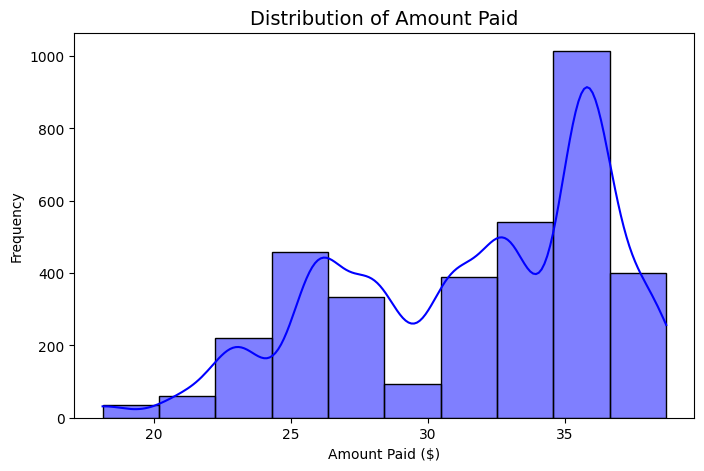

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(data = coffee_sales,
             x='money',
             bins= 10,
             kde=True,
             color='blue')

plt.title('Distribution of Amount Paid', fontsize = 14)
plt.xlabel('Amount Paid ($)')
plt.ylabel('Frequency')

plt.show()

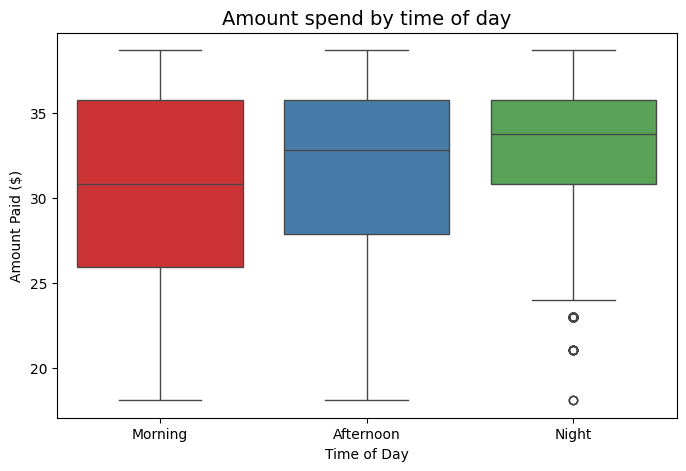

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data = coffee_sales,
    x = 'Time_of_Day',
    y= 'money',
    hue = 'Time_of_Day',
    palette='Set1'
)

plt.title('Amount spend by time of day', fontsize = 14)
plt.xlabel('Time of Day')
plt.ylabel('Amount Paid ($)')

plt.show()

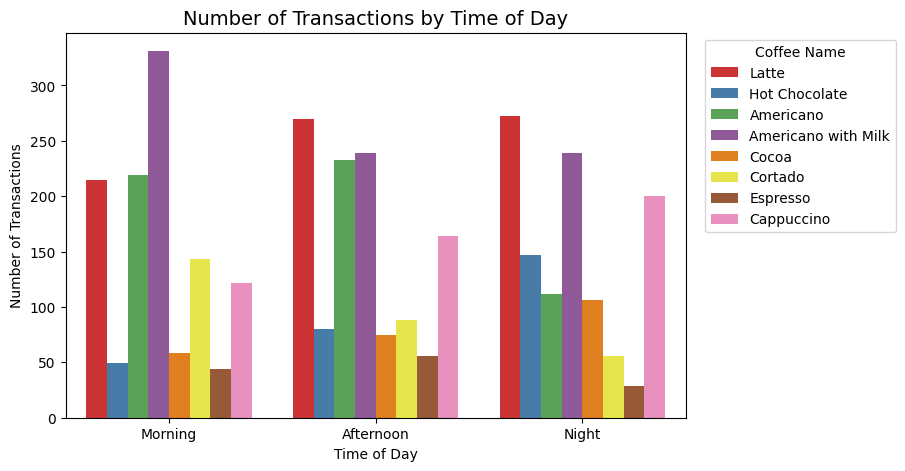

In [17]:
coffee_sales['transaction_count'] = 1

plt.figure(figsize=(8,5))

sns.barplot(
    data = coffee_sales,
    x = 'Time_of_Day',
    y='transaction_count',
    palette='Set1',
    hue='coffee_name',
    estimator='sum'
)

plt.title('Number of Transactions by Time of Day', fontsize = 14)
plt.xlabel('Time of Day')
plt.ylabel('Number of Transactions')
plt.legend(title='Coffee Name', loc='upper right', bbox_to_anchor=(1.35, 1))
plt.show()

In [19]:
coffee_sales_by_hour = coffee_sales.groupby('hour_of_day')['money'].sum().reset_index()
coffee_sales_by_hour

,hour_of_day,money
0,6,149.40
1,7,2846.02
2,8,7017.88
3,9,7264.28
4,10,10198.52
5,11,8453.10
6,12,7419.62
7,13,7028.76
8,14,7173.80
9,15,7476.02


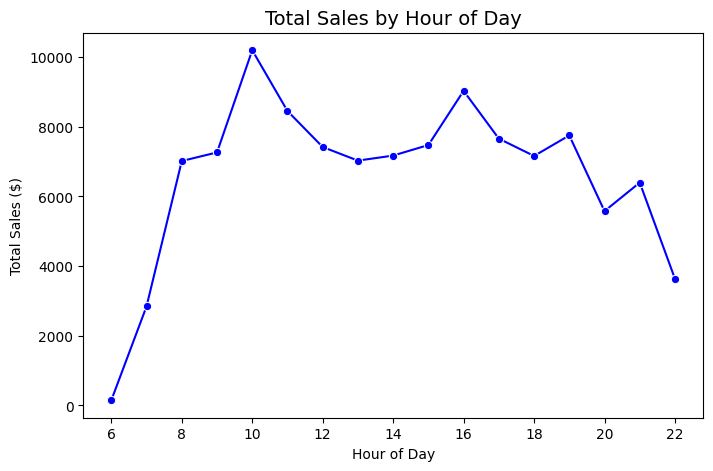

In [21]:
plt.figure(figsize = (8,5))

sns.lineplot(
    data = coffee_sales_by_hour,
    x = 'hour_of_day',
    y = 'money',
    marker='o',
    color= 'blue'
)

plt.title('Total Sales by Hour of Day', fontsize = 14)
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales ($)')
plt.show()

In [22]:
day_totals = coffee_sales.groupby(['Weekday', 'Weekdaysort'])['money'].sum().reset_index().sort_values('Weekdaysort')
day_totals

,Weekday,Weekdaysort,money
1,Mon,1,17363.10
5,Tue,2,18168.38
6,Wed,3,15750.46
4,Thu,4,16091.40
0,Fri,5,16802.66
2,Sat,6,14733.52
3,Sun,7,13336.06


In [24]:
heatsmap_data = day_totals['money'].values.reshape(1,-1)
heatsmap_data

array([[17363.1 , 18168.38, 15750.46, 16091.4 , 16802.66, 14733.52,
        13336.06]])

<Axes: >

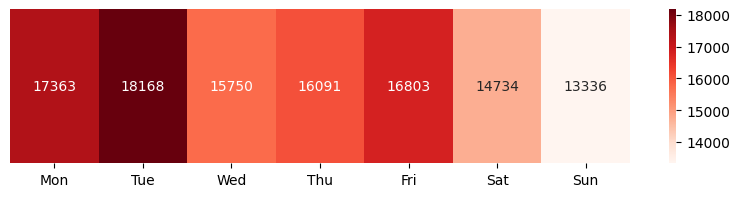

In [28]:
plt.figure(figsize=(10,2))

sns.heatmap(
    data = heatsmap_data,
    cmap='Reds',
    annot=True,
    fmt='.0f',
    xticklabels=day_totals['Weekday'],
    yticklabels=[]
)